# Final Model Evaluation

In `notebooks/reproducibility/02_` and `03_`, we pursued twin objectives: one focused on handcrafted feature extraction with Classical ML, and the other leveraging transfer learning on Deep Learning architectures.

Here, those paths converge. We will take the definitive champion from the ML track and the ultimate champion from the DL track, and pit them against each other on the unseen hold-out **Test Set**.

## 1. Final Model Champions

> Write your selection logic here for the DL model (MobileNetV2) and the ML model (Random Forest / SVM).

**Deep Learning Champion:**
- **Model:** MobileNetV2
- **Specs:** Level 1 (ImageNet), 256x256, 0.1 Dropout
- **Note:** As proven by our exhaustive learning rate grid search with extended early stopping patience, the model strictly caps at ~90% accuracy due to innate multi-label characteristics inside the dataset (i.e. leaves presenting multiple diseases concurrently while ground-truth labels force a single class).

**Classical ML Champion:**
- **Model:** Random Forest-Crafted
- **Specs:**
  - max-depth: 15
  - max features: sqrt
  - minimum sample split: 2
  - n estimators: 10
- **Note:** Our grid search tuning has led our model to an accuracy of ~76% wherein our model generally seem to struggle in fully utilizing the crafted features as demonstrated by how our data is distributed in our latent space analsysis which led us to trying deep learning alternatives.

## 2. Evaluation on the Hold-Out Test Set

> Write the data visualization logic to load your hold-out metrics or predictions here.

In [ ]:
# Your loading logic here...

In [9]:
import wandb
import pandas as pd

api = wandb.Api()

ENTITY = "grade-descent"
PROJECT = "jute-disease-detection"

comparison_runs = {
    "Champion RF": "5ujoflpj",
    "Deep Learning": "af60c7b9"
}

results = []

for model_name, run_id in comparison_runs.items():
    path = f"{ENTITY}/{PROJECT}/{run_id}"
    try:
        run = api.run(path)
        s = run.summary

        metrics = {
            "Model": model_name,
            "Accuracy": s.get("test_acc"),
            "Macro F1": s.get("test_f1"),
            "Precision": s.get("test_precision"),
            "Recall": s.get("test_recall"),
            "Run ID": run_id
        }
        results.append(metrics)
        print(f"Successfully fetched metrics for {model_name}")

    except Exception as e:
        print(f"Error fetching {run_id}: {e}")

df = pd.DataFrame(results)

styled_df = df.style.format({
    "Accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}"
}).hide(axis='index')

display(styled_df)

Successfully fetched metrics for Champion RF
Successfully fetched metrics for Deep Learning


Model,Accuracy,Macro F1,Precision,Recall,Run ID
Champion RF,0.7639,0.7128,0.7936,0.7213,5ujoflpj
Deep Learning,0.9139,0.9136,0.9049,0.9267,af60c7b9


We evaluated the generalization performance of our best models on the unseen test data.

**Metrics Breakdown**

| Model | Test Accuracy | Macro-F1 | Precision | Recall |
| :--- | :--- | :--- | :--- | :--- |
| Deep Learning (MobileNetV2) | - | - | - | - |
| Classical ML | - | - | - | - |


### Confusion Matrices

> Plot the side-by-side Confusion Matrices derived from Test set predictions.

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


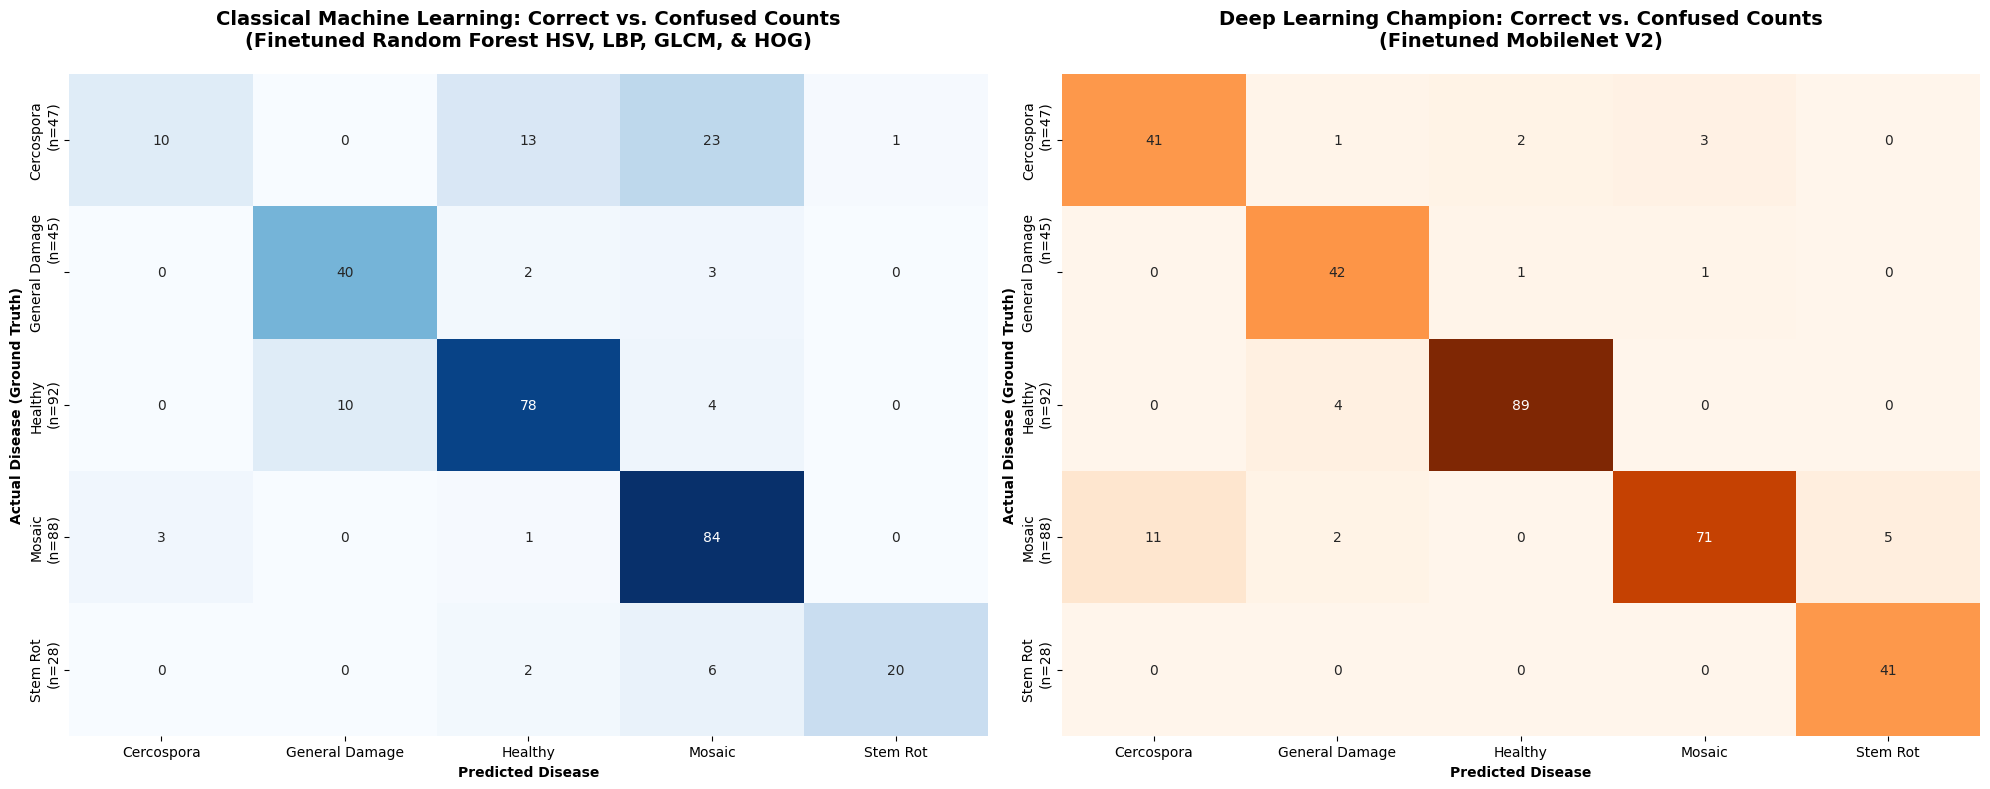

In [26]:
import wandb
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

api = wandb.Api()
ENTITY = "grade-descent"
PROJECT = "jute-disease-detection"

paths = {
    "Champion RF": f"{ENTITY}/{PROJECT}/run-5ujoflpj-conf_mat_table:v0",
    "Deep Learning": f"{ENTITY}/{PROJECT}/run-af60c7b9-test_conf_mat_table:v0"
}

jute_classes = ["Cercospora", "General Damage", "Healthy", "Mosaic", "Stem Rot"]

def get_pivot_from_artifact(artifact_path):
    artifact = api.artifact(artifact_path)
    artifact_dir = artifact.download()
    json_file = next(Path(artifact_dir).glob("*.json"))

    with open(json_file) as f:
        raw_data = json.load(f)

    df = pd.DataFrame(raw_data["data"], columns=raw_data["columns"])

    name_map = {
        "Cercospora Leaf Spot": "Cercospora",
    }

    df['Actual'] = df['Actual'].replace(name_map)
    df['Predicted'] = df['Predicted'].replace(name_map)

    val_col = "n" if "n" in df.columns else "nPredictions"

    pivot = df.groupby(['Actual', 'Predicted'])[val_col].sum().unstack().fillna(0)
    pivot = pivot.reindex(index=jute_classes, columns=jute_classes, fill_value=0)
    return pivot

cm_rf = get_pivot_from_artifact(paths["Champion RF"])
cm_dl = get_pivot_from_artifact(paths["Deep Learning"])

class_totals = cm_rf.sum(axis=1).astype(int)
new_labels = [f"{cls}\n(n={total})" for cls, total in zip(jute_classes, class_totals)]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_rf, annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=jute_classes, yticklabels=new_labels, cbar=False)
axes[0].set_title("Classical Machine Learning: Correct vs. Confused Counts\n(Finetuned Random Forest HSV, LBP, GLCM, & HOG)",
                  fontsize=14, pad=20, fontweight='bold')
axes[0].set_ylabel('Actual Disease (Ground Truth)', fontweight='bold')
axes[0].set_xlabel('Predicted Disease', fontweight='bold')

sns.heatmap(cm_dl, annot=True, fmt='g', cmap='Oranges', ax=axes[1],
            xticklabels=jute_classes, yticklabels=new_labels, cbar=False)
axes[1].set_title("Deep Learning Champion: Correct vs. Confused Counts\n(Finetuned MobileNet V2)",
                  fontsize=14, pad=20, fontweight='bold')
axes[1].set_ylabel('Actual Disease (Ground Truth)', fontweight='bold')
axes[1].set_xlabel('Predicted Disease', fontweight='bold')

plt.tight_layout()

Path("artifacts").mkdir(exist_ok=True)
plt.savefig("artifacts/rf_vs_dl_comparison_counts.png", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
import pandas as pd

def get_per_class_metrics(cm_pivot, model_name):
    metrics_list = []
    total_samples = cm_pivot.values.sum()
    classes = cm_pivot.index.tolist()

    for cls in classes:
        tp = cm_pivot.loc[cls, cls]
        fp = cm_pivot[cls].sum() - tp
        fn = cm_pivot.loc[cls].sum() - tp
        tn = total_samples - (tp + fp + fn)

        accuracy = (tp + tn) / total_samples
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        metrics_list.append({
            "Class": cls,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "Support": int(tp + fn)
        })

    return pd.DataFrame(metrics_list)

df_rf_final = get_per_class_metrics(cm_rf, "Champion RF")
df_dl_final = get_per_class_metrics(cm_dl, "MobileNet V2")

print("Table 1: Per-Class Performance - Champion Random Forest")
styled_rf = df_rf_final.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}",
    "Recall": "{:.4f}", "F1-Score": "{:.4f}"
}).hide(axis='index')
display(styled_rf)

print("\nTable 2: Per-Class Performance - MobileNet V2")
styled_dl = df_dl_final.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}",
    "Recall": "{:.4f}", "F1-Score": "{:.4f}"
}).hide(axis='index')
display(styled_dl)

Table 1: Per-Class Performance - Champion Random Forest


Class,Accuracy,Precision,Recall,F1-Score,Support
Cercospora,0.8667,0.7692,0.2128,0.3333,47
General Damage,0.9500,0.8000,0.8889,0.8421,45
Healthy,0.8933,0.8125,0.8478,0.8298,92
Mosaic,0.8667,0.7000,0.9545,0.8077,88
Stem Rot,0.9700,0.9524,0.7143,0.8163,28



Table 2: Per-Class Performance - MobileNet V2


Class,Accuracy,Precision,Recall,F1-Score,Support
Cercospora,0.9459,0.7885,0.8723,0.8283,47
General Damage,0.9713,0.8571,0.9545,0.9032,44
Healthy,0.9777,0.9674,0.9570,0.9622,93
Mosaic,0.9299,0.9467,0.7978,0.8659,89
Stem Rot,0.9841,0.8913,1.0000,0.9425,41


## 3. Deep Learning vs. Classical ML: The Final Comparison

> Summarize the head-to-head.
- **Overall Performance**: Did DL significantly outperform ML, or was it surprisingly close?
- **Cost & Efficiency**: What is the difference in latency (inference time)? Classical ML might be faster but required extensive upfront feature extraction overhead (Gabor filters, GLCM). DL operates directly on raw pixels but requires GPU acceleration for scale.
- **Interpretability**: Classical models heavily rely on explicit texture boundaries. DL allows for spatial Grad-CAM heatmapping.




### 3A: Overall Performance
The DL model was able to noticeably outperform the ML model across all four classification metrics (accuracy, precision, recall, and F1-Macro). In addition to this, the confusion matrices show a

### 3B: Cost & Efficiency

### 3C: Interpretability

## 4. Conclusion and Future Directives

> Write your definitive paper conclusion.

- **Bottlenecks:** Single-label constraint on multi-symptom leaves explicitly caps performance.
- **Future Work:** Transitioning to a Multi-label Learning framework (e.g., using Binary Relevance or Sigmoid BCE) rather than standard Softmax Multi-class.
- **Practical Application:** Can this be deployed cleanly to an edge advice via ONNX/TFLite running on a Jute farmer's smartphone?